In [1]:
import pandas as pd
import os

# === CONFIGURATION ===
dir_path = 'Decon-COO-Results_Loy_Inflammatory-Syndromes'
files = [
    'CIBERSORTx_Results.txt',
    'NNLS_GSE255555_pedInflam_filtered_counts_CPM_GeneNames.txt',
    'nuSVR_Counts_Decon-COO-Results_Loy_Inflammatory-Syndromes.txt',
    'QP_GSE255555_pedInflam_filtered_counts_CPM_GeneNames_composition.txt',
    'TSP-BDa_Inner_100each_seed42_filtered_GSE255555_pedInflam_filtered_counts_CPM_GeneNames_BayesPrism_renamed.txt',
    'TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results.tsv',
    'TSP-HBA_Inner_100each_seed42_Loy_Inflammatory-Syndromes_MuSiC.txt'
]

method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

def normalize_to_100(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].div(df[numeric_cols].sum(axis=1), axis=0) * 100
    return df

def clean_dataframe(df, file):
    if (
        file.endswith('BayesPrism_renamed.txt') or
        file.endswith('MuSiC.txt') or
        file.startswith('CIBERSORTx_Results') or
        file.endswith('ReDeconv_results.tsv')
    ):
        if file.startswith('CIBERSORTx_Results'):
            df = df.drop(columns=['P-value', 'Correlation', 'RMSE'], errors='ignore')
        df = normalize_to_100(df)

    elif file.startswith('QP') or file.startswith('NNLS'):
        df = df.drop(columns=[
            'RMSE-Composition', 'r-Composition',
            'RMSE-PredictedCounts', 'r-PredictedCounts'
        ], errors='ignore')

    return df.round(5)

def detect_method(filename):
    return next((m for m in method_map if m in filename), None)

# === FIRST PASS: COLLECT ALL CELL TYPES ===
all_celltypes = set()
temp_dfs = []
for file in files:
    file_path = os.path.join(dir_path, file)
    df = pd.read_csv(file_path, sep='\t', index_col=0)
    df = clean_dataframe(df, file)
    all_celltypes.update(df.columns)  # keep full set
    temp_dfs.append((file, df))

# Remove metadata columns from all_celltypes
all_celltypes = {c for c in all_celltypes if c not in ['Method', 'Sample']}

# === SECOND PASS: ENSURE CONSISTENT COLUMNS ===
all_results = []
for file, df in temp_dfs:
    # reindex to ensure all cell types present
    df = df.reindex(columns=list(all_celltypes))  # fill_value=None (default)

    method = detect_method(file)
    df['Method'] = method
    df['Sample'] = df.index
    all_results.append(df.reset_index(drop=True))

# === MERGE AND SAVE ===
merged_df = pd.concat(all_results, ignore_index=True)
output_file = os.path.join(dir_path, 'merged_normalised_results_Loy_Inflammatory-Syndromes.txt')
merged_df.to_csv(output_file, sep='\t', index=False)
print(f"Merged results saved to: {output_file}")


Merged results saved to: Decon-COO-Results_Loy_Inflammatory-Syndromes/merged_normalised_results_Loy_Inflammatory-Syndromes.txt


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, patches
import matplotlib as mpl


sns.set_theme(style="white", context="paper")  # context scales fonts nicely

mpl.rcParams.update({
    # Fonts (Illustrator-friendly)
    "font.family": "DejaVu Sans",
    "font.sans-serif": ["DejaVu Sans"],

    # Keep text as text in vector outputs
    "svg.fonttype": "none",     # <-- key for editable text in SVG
    "pdf.fonttype": 42,         # TrueType fonts embedded in PDF (also editable)
    "ps.fonttype": 42,

    # Sizes (tweak if needed)
    "font.size": 9,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 13,

    # Lines
    "axes.linewidth": 0.8,
    "hatch.linewidth": 1.2,

    # Save
    "savefig.bbox": "tight",
    "savefig.transparent": True,  # handy for Illustrator layouts
})

# ---------- Load results ----------
results_df = pd.read_csv("AllCellTypes_ALT_Normal_vs_High_BH_corrected.csv")

# ---------- Filter to relevant cell types ----------
celltype_map = {
    "hepatocyte": "Hepatocyte",
    "intrahepatic cholangiocyte": "Intrahepatic cholangiocyte",
    "pancreatic a cell": "Pancreatic a cell",
    "pancreatic a cell/pancreatic d cell/type b pancreatic cell": "Pancreatic a/d/type b cell",
    "kidney epithelial cell": "Kidney epithelial cell",
    "mesothelial cell": "Mesothelial cell",
    "mesothelial cell/schwann cell": "Mesothelial/Schwann cell",
    "myeloid dendritic cell": "Myeloid dendritic cell",
    "gamma-delta t cell": "Gamma-delta T cell",
    "cd8-positive, alpha-beta t cell/naive thymus-derived cd8-positive, alpha-beta t cell": "CD8+ T cell",
    "leukocyte": "Leukocyte"
}

results_df = results_df[results_df["CellType"].isin(celltype_map.keys())].copy()
results_df["CellTypeGroup"] = results_df["CellType"].map(celltype_map)

# ---------- Pivot for heatmap ----------
heatmap_data = results_df.pivot(index="CellTypeGroup", columns="Method", values="Delta_High_minus_Normal")
annot_data = results_df.pivot(index="CellTypeGroup", columns="Method", values="Stars_BH")
annot_data = annot_data.replace("ns", "")

# ---------- Order rows and columns ----------
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
cell_order = [
    "Hepatocyte",
    "Intrahepatic cholangiocyte",
    "Pancreatic a cell",
    "Pancreatic a/d/type b cell",
    "Kidney epithelial cell",
    "Myeloid dendritic cell",
    "Gamma-delta T cell",
    "CD8+ T cell",
    "Leukocyte"
]

heatmap_data = heatmap_data.reindex(cell_order)[tool_order]
annot_data   = annot_data.reindex(cell_order)[tool_order]
mask = heatmap_data.isna()

# ---------- Transpose for plotting ----------
heatmap_plot = heatmap_data.T
annot_plot   = annot_data.T
mask_plot    = mask.T

# ---------- Plot ----------
plt.figure(figsize=(4, 3))
cmap = plt.cm.get_cmap("RdBu_r").copy()
cmap.set_bad(color="lightgrey")

ax = sns.heatmap(
    heatmap_plot,
    annot=annot_plot,
    fmt="",
    cmap=cmap,
    center=0,
    linewidths=0.7,
    linecolor="white",
    mask=mask_plot,
    annot_kws={"fontsize": 9, "fontweight": "bold"},
)


# ---------- Add hatched overlay for missing cells ----------
for y in range(heatmap_plot.shape[0]):      # methods
    for x in range(heatmap_plot.shape[1]):  # cell types
        if mask_plot.iloc[y, x]:
            rect = patches.Rectangle(
                (x, y), 1, 1,
                facecolor="none",
                edgecolor="white",
                hatch="////",
                linewidth=0.0
            )
            ax.add_patch(rect)

# ---------- Labels and formatting ----------
#ax.set_title("Difference in cell-type proportions (High − Normal ALT)", pad=16, fontweight="bold")
# Axis labels
ax.set_xlabel("Cell Type", fontsize=8, labelpad=6)
ax.set_ylabel("Deconvolution Method", fontsize=8, labelpad=6)

# Tick labels
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

star_set = {"*", "**", "***", "****"}
for t in ax.texts:
    if t.get_text() in star_set:
        t.set_fontsize(7)
        t.set_fontweight("bold")
        t.set_ha("center")
        t.set_va("center")

# ---- Colorbar formatting ----
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.set_label(
    "Δ (High − Normal ALT) median contribution (%)",
    fontsize=8,
    rotation=270,
    labelpad=12
)

# ---------- Clean aesthetics ----------
sns.despine(left=True, bottom=True)
plt.tight_layout()
# ---------- Save ----------
fig = plt.gcf()
ax = plt.gca()

fig.savefig("Heatmap_ALT_High_vs_Normal_LoyDataset_Transposed.svg", format="svg", bbox_inches="tight")
plt.close()

/tmp/ipykernel_2984488/1418371082.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdBu_r").copy()


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, patches
import matplotlib as mpl

sns.set_theme(style="white", context="paper")  # context scales fonts nicely

mpl.rcParams.update({
    # Fonts (Illustrator-friendly)
    "font.family": "DejaVu Sans",
    "font.sans-serif": ["DejaVu Sans"],

    # Keep text as text in vector outputs
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Sizes
    "font.size": 9,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 13,

    # Lines
    "axes.linewidth": 0.8,
    "hatch.linewidth": 1.2,

    # Save
    "savefig.bbox": "tight",
    "savefig.transparent": True,
})

# ---------- Helper: standardised heatmap sizing (content-driven) ----------
def fig_for_heatmap(data, cell_in=0.30,
                    left_in=1.1, right_in=0.9,
                    bottom_in=1.0, top_in=0.3):
    """
    Figure size is derived from the heatmap matrix shape.
    Cell size is fixed (cell_in), margins are fixed (inches).
    """
    nrows, ncols = data.shape
    fig_w = ncols * cell_in + left_in + right_in
    fig_h = nrows * cell_in + top_in + bottom_in

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.subplots_adjust(
        left=left_in / fig_w,
        right=1 - right_in / fig_w,
        bottom=bottom_in / fig_h,
        top=1 - top_in / fig_h
    )
    return fig, ax


# ---------- Load results ----------
results_df = pd.read_csv("AllCellTypes_ALT_Normal_vs_High_BH_corrected.csv")

# ---------- Filter to relevant cell types ----------
celltype_map = {
    "hepatocyte": "Hepatocyte",
    "intrahepatic cholangiocyte": "Intrahepatic cholangiocyte",
    "pancreatic a cell": "Pancreatic a cell",
    "pancreatic a cell/pancreatic d cell/type b pancreatic cell": "Pancreatic a/d/type b cell",
    "kidney epithelial cell": "Kidney epithelial cell",
    "mesothelial cell": "Mesothelial cell",
    "mesothelial cell/schwann cell": "Mesothelial/Schwann cell",
    "myeloid dendritic cell": "Myeloid dendritic cell",
    "gamma-delta t cell": "Gamma-delta T cell",
    "cd8-positive, alpha-beta t cell/naive thymus-derived cd8-positive, alpha-beta t cell": "CD8+ T cell",
    "leukocyte": "Leukocyte"
}

results_df = results_df[results_df["CellType"].isin(celltype_map.keys())].copy()
results_df["CellTypeGroup"] = results_df["CellType"].map(celltype_map)

# ---------- Pivot for heatmap ----------
heatmap_data = results_df.pivot(index="CellTypeGroup", columns="Method", values="Delta_High_minus_Normal")
annot_data = results_df.pivot(index="CellTypeGroup", columns="Method", values="Stars_BH").replace("ns", "")

# ---------- Order rows and columns ----------
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
cell_order = [
    "Hepatocyte",
    "Intrahepatic cholangiocyte",
    "Pancreatic a cell",
    "Pancreatic a/d/type b cell",
    "Kidney epithelial cell",
    "Myeloid dendritic cell",
    "Gamma-delta T cell",
    "CD8+ T cell",
    "Leukocyte"
]

heatmap_data = heatmap_data.reindex(cell_order)[tool_order]
annot_data   = annot_data.reindex(cell_order)[tool_order]
mask = heatmap_data.isna()

# ---------- Transpose for plotting ----------
heatmap_plot = heatmap_data.T
annot_plot   = annot_data.T
mask_plot    = mask.T

# ---------- Plot (standardised cell size) ----------
cmap = plt.cm.get_cmap("RdBu_r").copy()
cmap.set_bad(color="lightgrey")

fig, ax = fig_for_heatmap(
    heatmap_plot,
    cell_in=0.30,   # cell square size (inches)
    left_in=1.1,    # space for y labels
    right_in=0.9,   # space for colorbar
    bottom_in=1.0,  # space for rotated x labels
    top_in=0.3
)

ax = sns.heatmap(
    heatmap_plot,
    annot=annot_plot,
    fmt="",
    cmap=cmap,
    center=0,
    linewidths=0.7,
    linecolor="white",
    mask=mask_plot,
    square=True,  # keep cells square
    annot_kws={"fontsize": 9, "fontweight": "bold"},
    ax=ax
)

# ---------- Add hatched overlay for missing cells ----------
for y in range(heatmap_plot.shape[0]):      # methods
    for x in range(heatmap_plot.shape[1]):  # cell types
        if mask_plot.iloc[y, x]:
            ax.add_patch(
                patches.Rectangle(
                    (x, y), 1, 1,
                    facecolor="none",
                    edgecolor="white",
                    hatch="////",
                    linewidth=0.0
                )
            )

# ---------- Labels and formatting ----------
ax.set_xlabel("Cell Type", fontsize=8, labelpad=6)
ax.set_ylabel("Deconvolution Method", fontsize=8, labelpad=6)

ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# ---------- Stars formatting ----------
star_set = {"*", "**", "***", "****"}
for t in ax.texts:
    if t.get_text() in star_set:
        t.set_fontsize(7)
        t.set_fontweight("bold")
        t.set_ha("center")
        t.set_va("center")

# ---- Colorbar formatting ----
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.set_label(
    "Δ (High − Normal ALT) median contribution (%)",
    fontsize=8,
    rotation=270,
    labelpad=12
)

sns.despine(left=True, bottom=True)

# ---------- Save ----------
fig.savefig("Heatmap_ALT_High_vs_Normal_LoyDataset_Transposed.svg", format="svg", bbox_inches="tight")
plt.close(fig)


/tmp/ipykernel_2984488/1473582804.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdBu_r").copy()


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---------- Helper function ----------
def pval_to_star(p):
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------- Input files ----------
decon_file = "Decon-COO-Results_Loy_Inflammatory-Syndromes/merged_normalised_results_Loy_Inflammatory-Syndromes.txt"
meta_file  = "meta_ALT.csv"

# ---------- Load data ----------
decon = pd.read_csv(decon_file, sep="\t")
meta  = pd.read_csv(meta_file)

# Clean sample IDs for matching
meta["sample_id_clean"] = meta["sample_id"].str.replace("_trimmed", "", regex=False)
decon = decon.reset_index().rename(columns={"index": "sample_id"})

# Merge metadata with deconvolution results
merged = pd.merge(decon, meta, left_on="Sample", right_on="sample_id_clean")

# Ensure numeric for biochemical markers
merged["palt"]  = pd.to_numeric(merged["palt"], errors="coerce")
merged = merged.dropna(subset=["palt"])

# ---------- Define ALT categories ----------
merged["ALT_category"] = pd.NA
merged.loc[merged["palt"] < 40, "ALT_category"] = "Normal"
merged.loc[merged["palt"] > 100, "ALT_category"] = "High"
merged = merged.dropna(subset=["ALT_category"])

print(f"Matched unique samples: {merged['sample_id_clean'].nunique()}")
print(f"Matched rows (sample × tool): {merged.shape[0]}")

# ---------- Reshape to long format (only cell types) ----------
exclude_cols = [
    "Sample", "sample_id", "Method", "ALT_category",
    "palt", "sample_id_clean"
]

celltype_cols = [c for c in merged.columns if c not in exclude_cols]

long_df = merged.melt(
    id_vars=["Sample", "Method", "ALT_category"],
    value_vars=celltype_cols,
    var_name="CellType",
    value_name="Contribution"
)

# Ensure numeric contributions
long_df["Contribution"] = pd.to_numeric(long_df["Contribution"], errors="coerce")
long_df = long_df.dropna(subset=["Contribution"])

# ---------- Statistical testing (Normal vs High ALT) ----------
results = []

for (method, celltype), df_sub in long_df.groupby(["Method", "CellType"]):
    groups = {cat: vals["Contribution"].values for cat, vals in df_sub.groupby("ALT_category")}
    
    if "Normal" in groups and "High" in groups:
        normal_vals = groups["Normal"]
        high_vals   = groups["High"]

        if len(normal_vals) > 0 and len(high_vals) > 0:
            try:
                # Compute medians and Mann–Whitney U test
                median_normal = np.median(normal_vals)
                median_high   = np.median(high_vals)
                delta = median_high - median_normal
                stat, pval = mannwhitneyu(normal_vals, high_vals, alternative="two-sided")

                results.append({
                    "Method": method,
                    "CellType": celltype,
                    "pval": pval,
                    "Significant": pval < 0.05,
                    "Stars": pval_to_star(pval),
                    "Median_HighALT": median_high,
                    "Median_NormalALT": median_normal,
                    "Delta_High_minus_Normal": delta,
                    "Direction": "High ALT > Normal" if delta > 0 else "Normal > High ALT"
                })
            except Exception as e:
                print(f"Skipping {method} - {celltype}: {e}")

# ---------- Collect results ----------
results_df = pd.DataFrame(results)

# ---------- Apply Benjamini–Hochberg correction (WITHIN TOOL) ----------
results_df["pval_BH"] = np.nan

for method, idx in results_df.groupby("Method").groups.items():
    valid = results_df.loc[idx, "pval"].dropna()
    if len(valid) == 0:
        continue
    _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
    results_df.loc[valid.index, "pval_BH"] = p_corr

results_df["Significant_BH"] = results_df["pval_BH"] < 0.05
results_df["Stars_BH"] = results_df["pval_BH"].apply(pval_to_star)

# ---------- Print significant results ----------
print("\n=== Statistically Significant Differences (FDR < 0.05, BH-WithinTool) ===")
sig_df = results_df[results_df["Significant_BH"]].sort_values("pval_BH")

if sig_df.empty:
    print("No significant differences found between ALT groups (BH-WithinTool).")
else:
    for _, row in sig_df.iterrows():
        arrow = "↑" if row["Delta_High_minus_Normal"] > 0 else "↓"
        print(f"{row['Method']:12s} | {row['CellType'][:40]:40s} | "
              f"FDR = {row['pval_BH']:.3e} {row['Stars_BH']:4s} | "
              f"{row['Direction']:20s} ({arrow}) | Δ = {row['Delta_High_minus_Normal']:.3f}")

# ---------- Save all results ----------
results_df.to_csv("AllCellTypes_ALT_Normal_vs_High_BH_WithinTool.csv", index=False)
print("\nFull statistical results saved to: AllCellTypes_ALT_Normal_vs_High_BH_WithinTool.csv")

# ---------- Save only significant with higher ALT ----------
sig_high = sig_df[sig_df["Direction"] == "High ALT > Normal"]
sig_high.to_csv("Significant_HighALT_higher_CellTypes_BH_WithinTool.csv", index=False)
print("Significant cell types with higher median in High ALT group saved to: Significant_HighALT_higher_CellTypes_BH_WithinTool.csv")


Matched unique samples: 36
Matched rows (sample × tool): 252

=== Statistically Significant Differences (FDR < 0.05, BH-WithinTool) ===
BayesPrism   | classical monocyte/intermediate monocyte | FDR = 1.339e-02 *    | Normal > High ALT    (↓) | Δ = -13.851
BayesPrism   | hepatocyte                               | FDR = 1.339e-02 *    | High ALT > Normal    (↑) | Δ = 0.299
BayesPrism   | myeloid dendritic cell                   | FDR = 1.339e-02 *    | High ALT > Normal    (↑) | Δ = 0.327
BayesPrism   | pancreatic a cell                        | FDR = 1.339e-02 *    | High ALT > Normal    (↑) | Δ = 0.003
nuSVR        | microglia                                | FDR = 1.627e-02 *    | Normal > High ALT    (↓) | Δ = -0.564
nuSVR        | stratified squamous epithelial cell      | FDR = 1.627e-02 *    | High ALT > Normal    (↑) | Δ = 0.394
nuSVR        | taste receptor cell                      | FDR = 1.627e-02 *    | Normal > High ALT    (↓) | Δ = -0.870
BayesPrism   | cd8-positive, alpha

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, patches
import matplotlib as mpl

sns.set_theme(style="white", context="paper")  # context scales fonts nicely

mpl.rcParams.update({
    # Fonts (Illustrator-friendly)
    "font.family": "DejaVu Sans",
    "font.sans-serif": ["DejaVu Sans"],

    # Keep text as text in vector outputs
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Sizes
    "font.size": 9,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 13,

    # Lines
    "axes.linewidth": 0.8,
    "hatch.linewidth": 1.2,

    # Save
    "savefig.bbox": "tight",
    "savefig.transparent": True,
})

# ---------- Helper: standardised heatmap sizing (content-driven) ----------
def fig_for_heatmap(data, cell_in=0.30,
                    left_in=1.1, right_in=0.9,
                    bottom_in=1.0, top_in=0.3):
    """
    Figure size is derived from the heatmap matrix shape.
    Cell size is fixed (cell_in), margins are fixed (inches).
    """
    nrows, ncols = data.shape
    fig_w = ncols * cell_in + left_in + right_in
    fig_h = nrows * cell_in + top_in + bottom_in

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.subplots_adjust(
        left=left_in / fig_w,
        right=1 - right_in / fig_w,
        bottom=bottom_in / fig_h,
        top=1 - top_in / fig_h
    )
    return fig, ax


# ---------- Load results ----------
results_df = pd.read_csv("AllCellTypes_ALT_Normal_vs_High_BH_WithinTool.csv")

# ---------- Filter to relevant cell types ----------
celltype_map = {
    "hepatocyte": "Hepatocyte",
    "intrahepatic cholangiocyte": "Intrahepatic cholangiocyte",
    "pancreatic a cell": "Pancreatic a cell",
    "pancreatic a cell/pancreatic d cell/type b pancreatic cell": "Pancreatic a/d/type b cell",
    "kidney epithelial cell": "Kidney epithelial cell",
    "mesothelial cell": "Mesothelial cell",
    "mesothelial cell/schwann cell": "Mesothelial/Schwann cell",
    "myeloid dendritic cell": "Myeloid dendritic cell",
    "gamma-delta t cell": "Gamma-delta T cell",
    "cd8-positive, alpha-beta t cell/naive thymus-derived cd8-positive, alpha-beta t cell": "CD8+ T cell",
    "leukocyte": "Leukocyte"
}

results_df = results_df[results_df["CellType"].isin(celltype_map.keys())].copy()
results_df["CellTypeGroup"] = results_df["CellType"].map(celltype_map)

# ---------- Pivot for heatmap ----------
heatmap_data = results_df.pivot(index="CellTypeGroup", columns="Method", values="Delta_High_minus_Normal")
annot_data = results_df.pivot(index="CellTypeGroup", columns="Method", values="Stars_BH").replace("ns", "")

# ---------- Order rows and columns ----------
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
cell_order = [
    "Hepatocyte",
    "Intrahepatic cholangiocyte",
    "Pancreatic a cell",
    "Pancreatic a/d/type b cell",
    "Kidney epithelial cell",
    "Myeloid dendritic cell",
    "Gamma-delta T cell",
    "CD8+ T cell",
    "Leukocyte"
]

heatmap_data = heatmap_data.reindex(cell_order)[tool_order]
annot_data   = annot_data.reindex(cell_order)[tool_order]
mask = heatmap_data.isna()

# ---------- Transpose for plotting ----------
heatmap_plot = heatmap_data.T
annot_plot   = annot_data.T
mask_plot    = mask.T

# ---------- Plot (standardised cell size) ----------
cmap = plt.cm.get_cmap("RdBu_r").copy()
cmap.set_bad(color="lightgrey")

fig, ax = fig_for_heatmap(
    heatmap_plot,
    cell_in=0.30,   # cell square size (inches)
    left_in=1.1,    # space for y labels
    right_in=0.9,   # space for colorbar
    bottom_in=1.0,  # space for rotated x labels
    top_in=0.3
)

ax = sns.heatmap(
    heatmap_plot,
    annot=annot_plot,
    fmt="",
    cmap=cmap,
    center=0,
    linewidths=0.7,
    linecolor="white",
    mask=mask_plot,
    square=True,  # keep cells square
    annot_kws={"fontsize": 9, "fontweight": "bold"},
    ax=ax
)

# ---------- Add hatched overlay for missing cells ----------
for y in range(heatmap_plot.shape[0]):      # methods
    for x in range(heatmap_plot.shape[1]):  # cell types
        if mask_plot.iloc[y, x]:
            ax.add_patch(
                patches.Rectangle(
                    (x, y), 1, 1,
                    facecolor="none",
                    edgecolor="white",
                    hatch="////",
                    linewidth=0.0
                )
            )

# ---------- Labels and formatting ----------
ax.set_xlabel("Cell Type", fontsize=8, labelpad=6)
ax.set_ylabel("Deconvolution Method", fontsize=8, labelpad=6)

ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# ---------- Stars formatting ----------
star_set = {"*", "**", "***", "****"}
for t in ax.texts:
    if t.get_text() in star_set:
        t.set_fontsize(7)
        t.set_fontweight("bold")
        t.set_ha("center")
        t.set_va("center")

# ---- Colorbar formatting ----
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.set_label(
    "Δ (High − Normal ALT) median contribution (%)",
    fontsize=8,
    rotation=270,
    labelpad=12
)

sns.despine(left=True, bottom=True)

# ---------- Save ----------
fig.savefig("Heatmap_ALT_High_vs_Normal_LoyDataset_Transposed_BH_WithinTool.svg", format="svg", bbox_inches="tight")
plt.close(fig)


/tmp/ipykernel_2984488/1798840157.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdBu_r").copy()


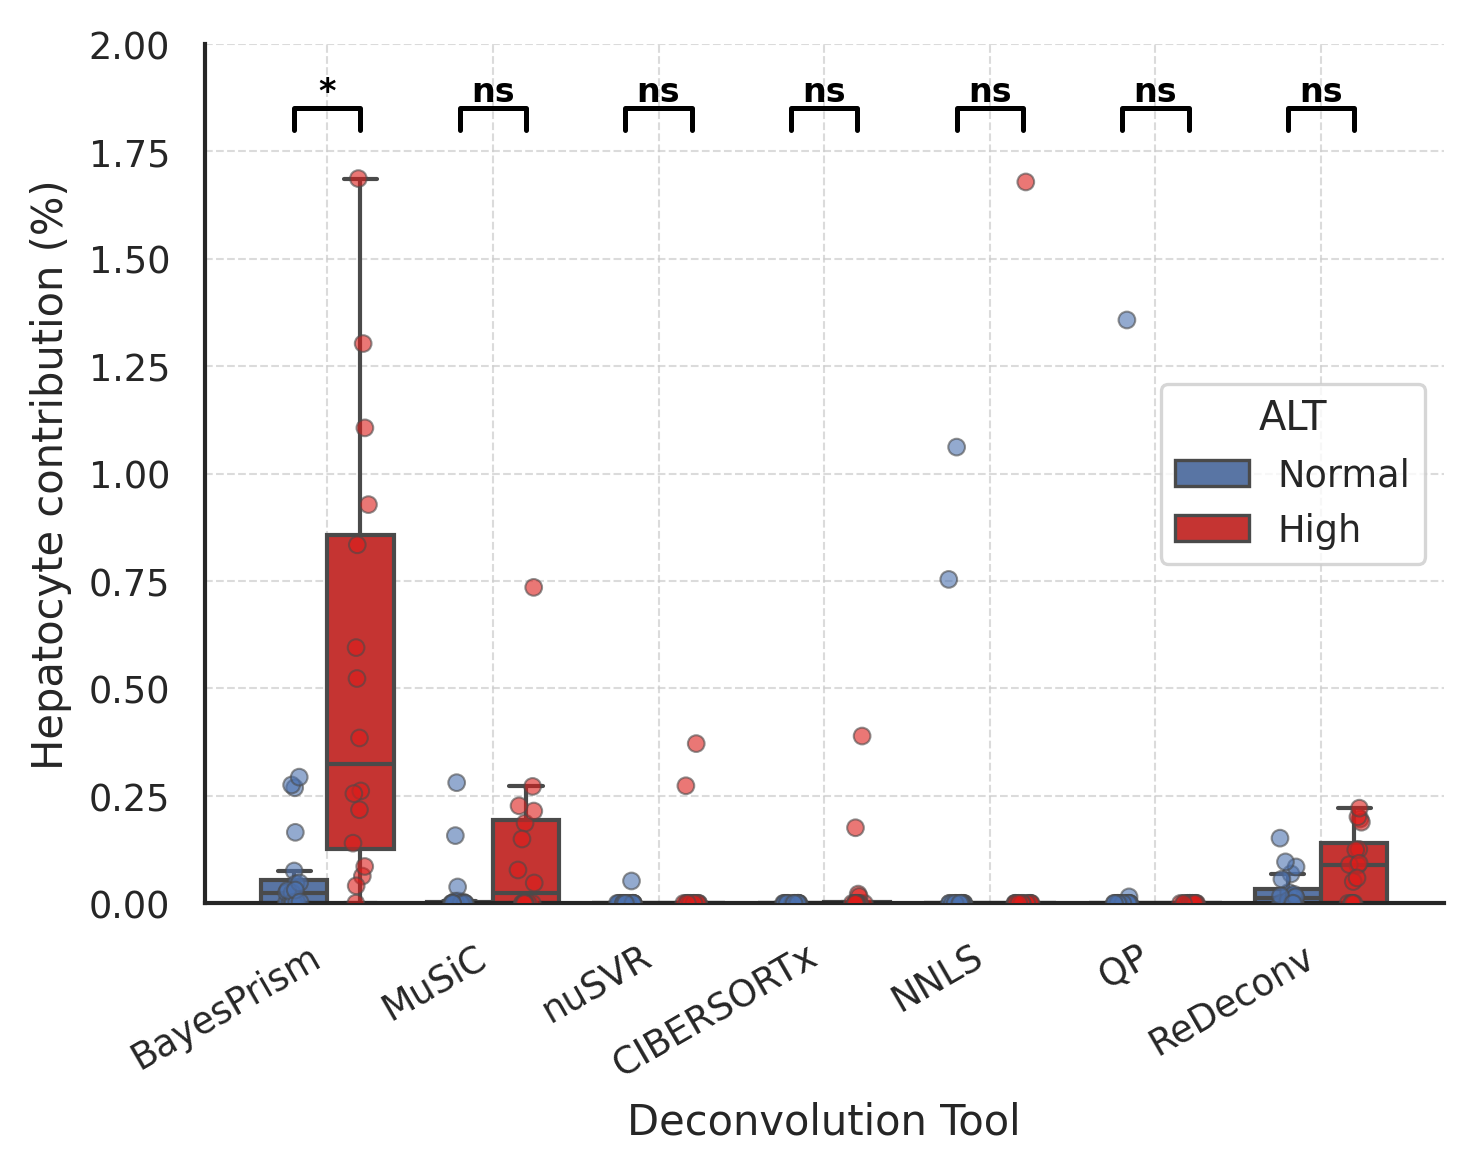

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

def pval_to_star(p):
    if pd.isna(p): return ""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def add_bracket(ax, x1, x2, y, text, height):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.2, c="black")
    ax.text((x1+x2)/2, y+height, text, ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="black")

# --------- inputs ----------
CELLTYPE = "hepatocyte"
results_csv = "AllCellTypes_ALT_Normal_vs_High_BH_WithinTool.csv"

tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
palette = {"Normal": "#4C72B0", "High": "#DD1C1A"}
hue_offsets = {"Normal": -0.20, "High": 0.20}

# --------- stars per tool (from results file) ----------
res = pd.read_csv(results_csv)
res_ct = res[res["CellType"].eq(CELLTYPE)].copy()
stars_map = dict(zip(res_ct["Method"], res_ct["Stars_BH"].fillna("")))

# --------- data to plot (from long_df already in memory) ----------
df_ct = long_df[long_df["CellType"].eq(CELLTYPE)].copy()
if df_ct.empty:
    raise ValueError(f"No rows found for CellType='{CELLTYPE}' in long_df.")

df_ct["Method"] = pd.Categorical(df_ct["Method"], categories=tool_order, ordered=True)
df_ct["ALT_category"] = pd.Categorical(df_ct["ALT_category"], categories=["Normal", "High"], ordered=True)

# --------- plot ----------
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=df_ct, x="Method", y="Contribution", hue="ALT_category",
    palette=palette, dodge=True, showfliers=False, ax=ax
)
sns.stripplot(
    data=df_ct, x="Method", y="Contribution", hue="ALT_category",
    palette=palette, dodge=True, jitter=True, alpha=0.6,
    linewidth=0.5, size=4, ax=ax
)

# legend once
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="ALT", frameon=True)

# fixed y-axis + bracket position
ax.set_ylim(0, 2)
base_y = 1.8
height = 0.05

# x positions for methods
xticks = ax.get_xticks()
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
tool_to_x = dict(zip(xticklabels, xticks))

for tool in tool_order:
    star = stars_map.get(tool, "")
    if tool in tool_to_x:
        x = tool_to_x[tool]
        add_bracket(ax, x + hue_offsets["Normal"], x + hue_offsets["High"], base_y, star, height)

ax.set_xlabel("Deconvolution Tool", fontsize=10)
ax.set_ylabel("Hepatocyte contribution (%)", fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
sns.despine()
plt.tight_layout()

plt.savefig("ALT_Normal_vs_High_Hepatocyte_Loy_Inflammatory_BH_WithinTool.svg", format="svg", bbox_inches="tight")
plt.show()


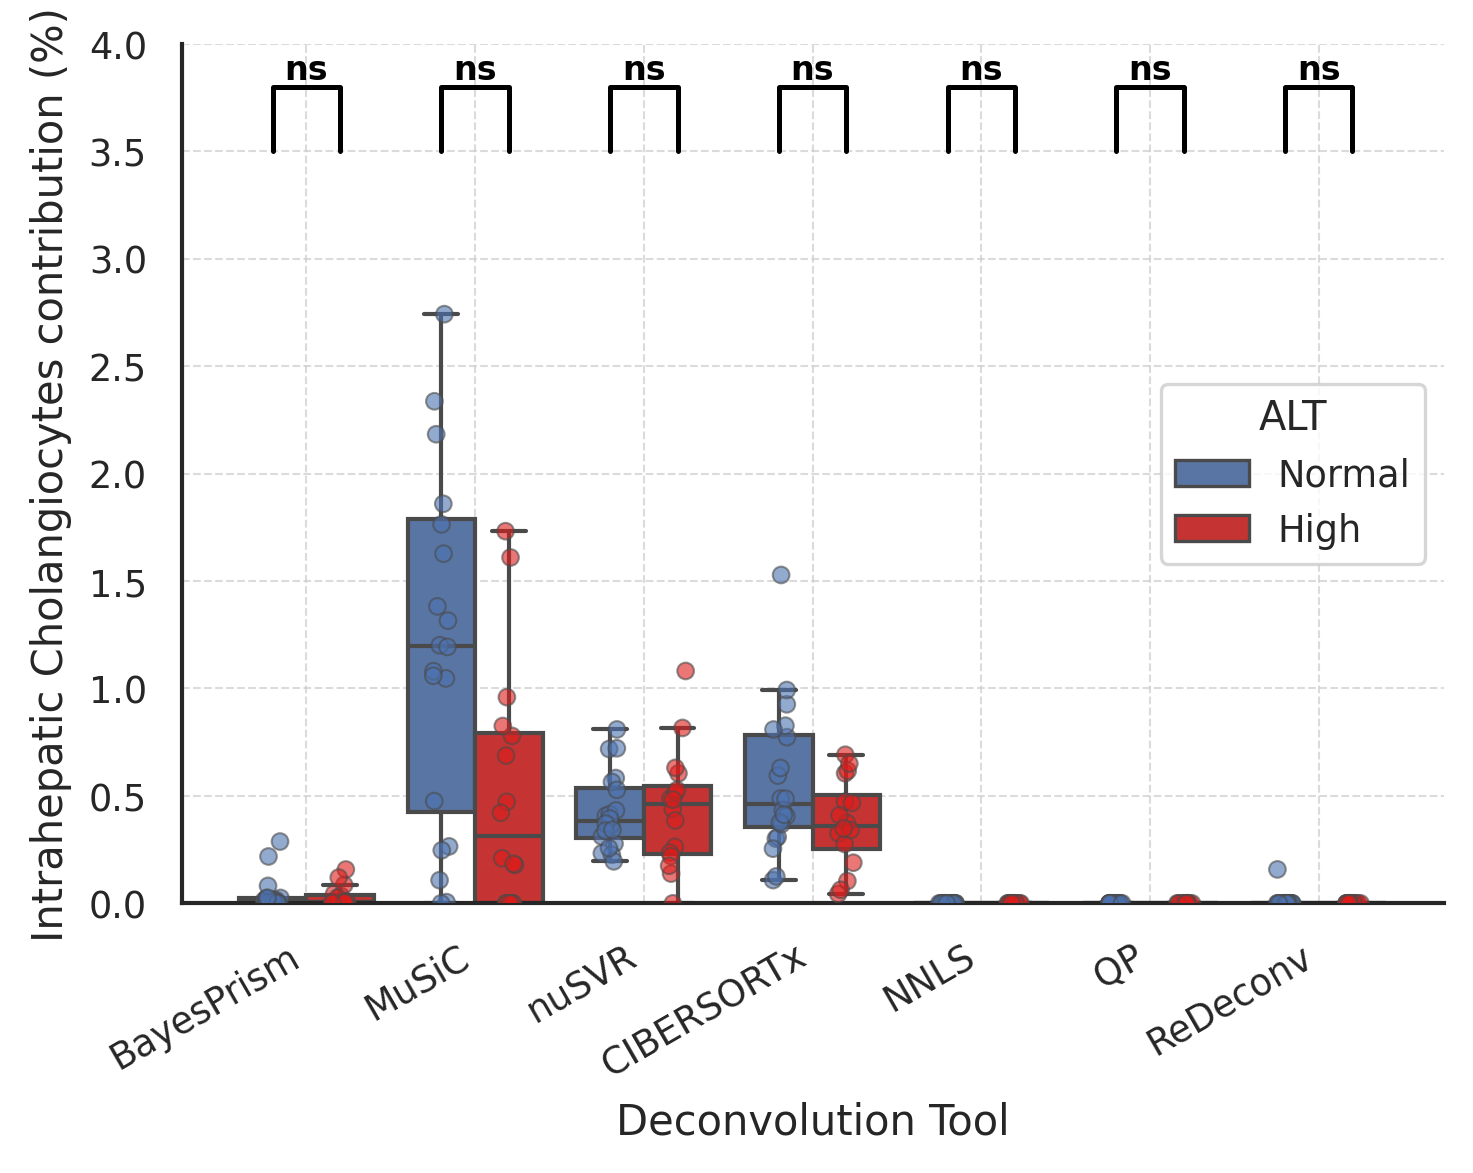

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

def pval_to_star(p):
    if pd.isna(p): return ""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def add_bracket(ax, x1, x2, y, text, height):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.2, c="black")
    ax.text((x1+x2)/2, y+height, text, ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="black")

# --------- inputs ----------
CELLTYPE = "intrahepatic cholangiocyte"
results_csv = "AllCellTypes_ALT_Normal_vs_High_BH_WithinTool.csv"

tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
palette = {"Normal": "#4C72B0", "High": "#DD1C1A"}
hue_offsets = {"Normal": -0.20, "High": 0.20}

# --------- stars per tool (from results file) ----------
res = pd.read_csv(results_csv)
res_ct = res[res["CellType"].eq(CELLTYPE)].copy()
stars_map = dict(zip(res_ct["Method"], res_ct["Stars_BH"].fillna("")))

# --------- data to plot (from long_df already in memory) ----------
df_ct = long_df[long_df["CellType"].eq(CELLTYPE)].copy()
if df_ct.empty:
    raise ValueError(f"No rows found for CellType='{CELLTYPE}' in long_df.")

df_ct["Method"] = pd.Categorical(df_ct["Method"], categories=tool_order, ordered=True)
df_ct["ALT_category"] = pd.Categorical(df_ct["ALT_category"], categories=["Normal", "High"], ordered=True)

# --------- plot ----------
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=df_ct, x="Method", y="Contribution", hue="ALT_category",
    palette=palette, dodge=True, showfliers=False, ax=ax
)
sns.stripplot(
    data=df_ct, x="Method", y="Contribution", hue="ALT_category",
    palette=palette, dodge=True, jitter=True, alpha=0.6,
    linewidth=0.5, size=4, ax=ax
)

# legend once
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="ALT", frameon=True)

# fixed y-axis + bracket position
ax.set_ylim(0, 4)
base_y = 3.5
height = 0.3

# x positions for methods
xticks = ax.get_xticks()
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
tool_to_x = dict(zip(xticklabels, xticks))

for tool in tool_order:
    star = stars_map.get(tool, "")
    if tool in tool_to_x:
        x = tool_to_x[tool]
        add_bracket(ax, x + hue_offsets["Normal"], x + hue_offsets["High"], base_y, star, height)

ax.set_xlabel("Deconvolution Tool", fontsize=10)
ax.set_ylabel("Intrahepatic Cholangiocytes contribution (%)", fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
sns.despine()
plt.tight_layout()

plt.savefig("ALT_Normal_vs_High_IntrahepaticCholangiocytes_Loy_Inflammatory_BH_WithinTool.svg", format="svg", bbox_inches="tight")
plt.show()
